In [1]:
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Data load করো
X = np.load('../data/processed/X_features.npy')
y = np.load('../data/processed/y_labels.npy')

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3504, 232414)
Test size: (876, 232414)


In [2]:
# Random Forest train করো
print("Training model... (একটু সময় লাগবে)")

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # সব CPU core ব্যবহার করবে
)
model.fit(X_train, y_train)

print("✅ Training complete!")

Training model... (একটু সময় লাগবে)
✅ Training complete!


In [3]:
# Prediction করো
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc*100:.2f}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Accuracy: 91.10%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       106
           1       1.00      0.85      0.92       107
           2       1.00      0.96      0.98        70
           3       0.77      0.98      0.86       134
           4       0.98      0.86      0.92       142
           5       1.00      0.77      0.87        48
           6       0.93      0.94      0.94       269

    accuracy                           0.91       876
   macro avg       0.93      0.90      0.91       876
weighted avg       0.92      0.91      0.91       876



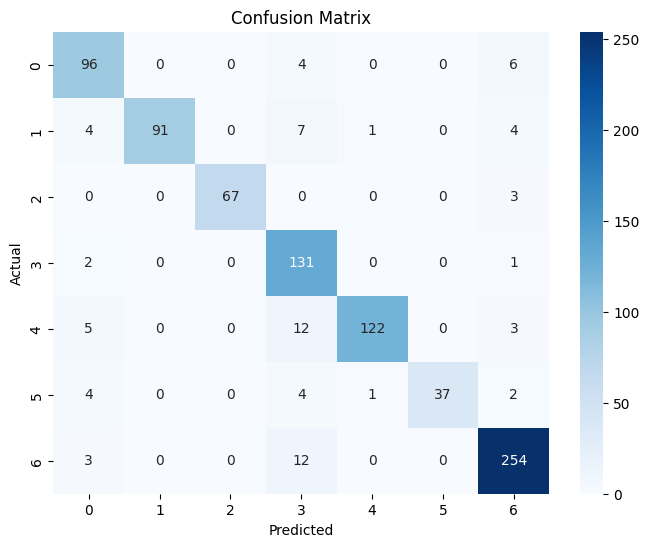

In [4]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [5]:
with open('../models/dna_classifier.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved to models/dna_classifier.pkl")

✅ Model saved to models/dna_classifier.pkl
